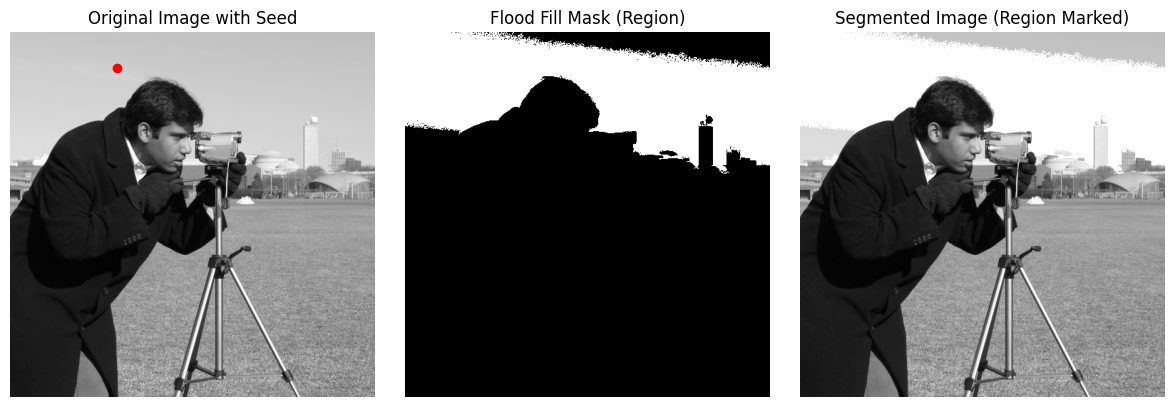

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color

# 1. Memuat citra (contoh: camera)
image_camera = data.camera()

# 2. Tentukan titik 'seed' (benih)
seed_point = (50, 150)

# 3. Terapkan algoritma flood fill (mirip region growing)
# 'tolerance' menentukan seberapa besar perbedaan intensitas yang diizinkan
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

# 4. Buat citra tersegmentasi (tandai region yang 'tumbuh')
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255  # Tandai region dengan warna putih

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap=plt.cm.gray)
ax[0].plot(seed_point[1], seed_point[0], 'ro')  # Tandai seed point
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap=plt.cm.gray)
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap=plt.cm.gray)
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

Tugas lanjutan:
Amati region yang dihasilkan oleh algoritma flood. Bagaimana pengaruh parameter tolerance terhadap ukuran region yang 'tumbuh'? Cobalah mengubah titik seed dan nilai tolerance.

PENGARUH PARAMETER TOLERANCE PADA FLOOD FILL


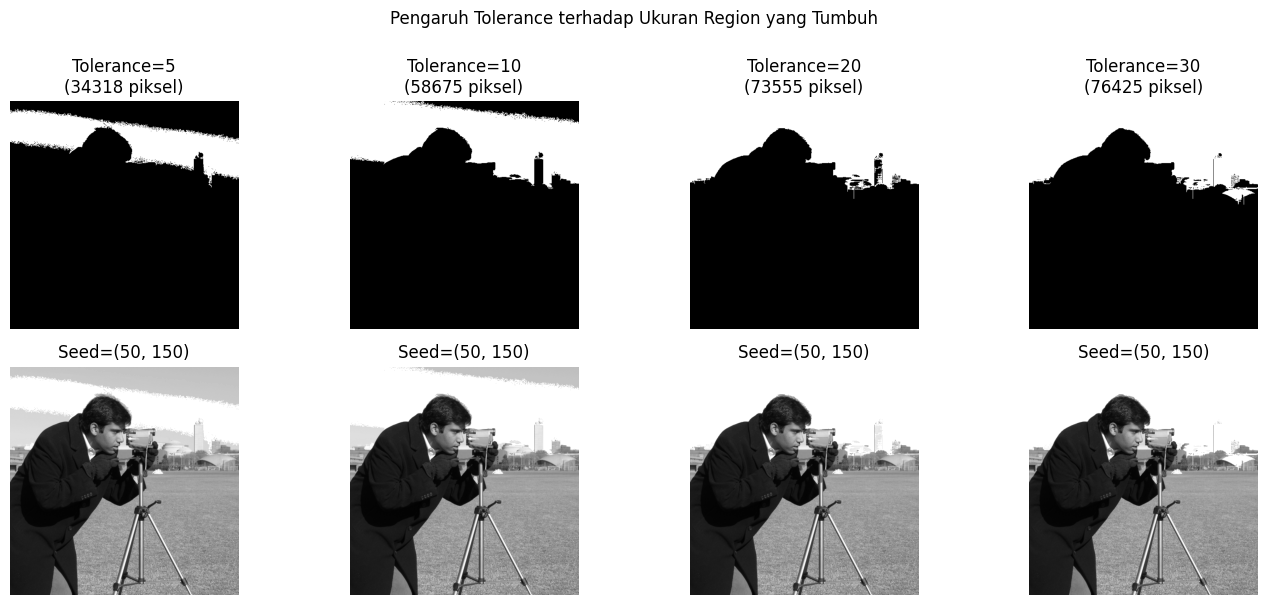


✓ OBSERVASI:
- Tolerance rendah (5): Region tumbuh lebih kecil, hanya piksel sangat mirip
- Tolerance tinggi (30): Region tumbuh lebih besar, mencakup piksel lebih berbeda
- Seed point: (50, 150)

PENGARUH SEED POINT PADA HASIL FLOOD FILL


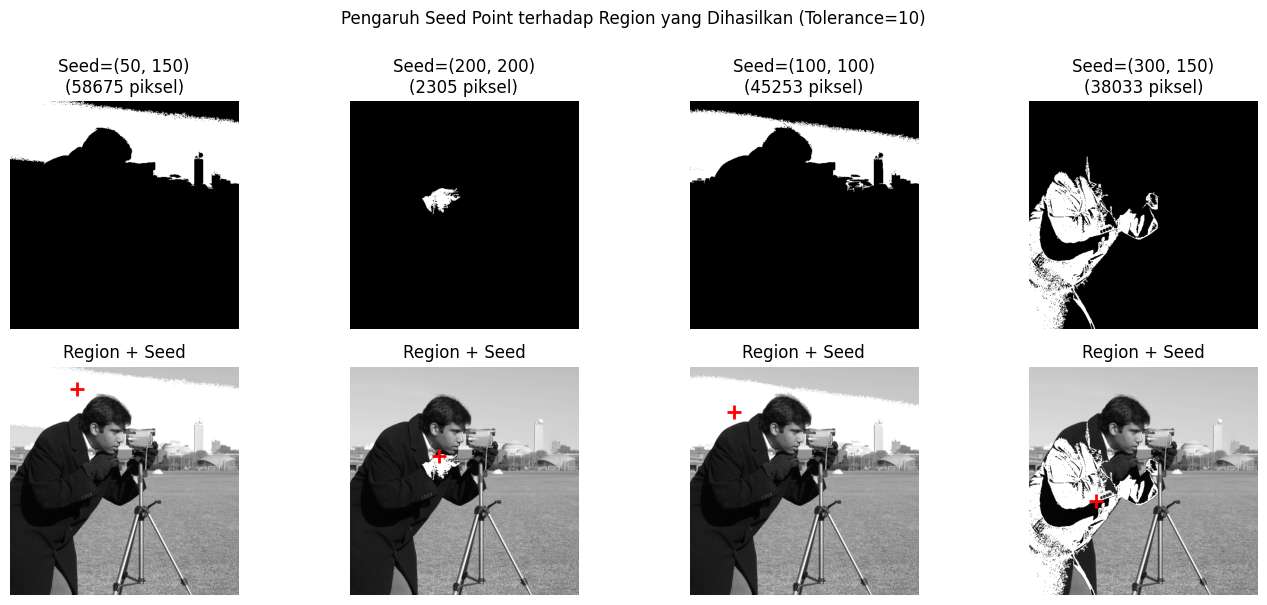


✓ KESIMPULAN:
- Seed point di area terang menghasilkan region luas
- Seed point di area gelap menghasilkan region lebih kecil
- Tolerance mengontrol 'kelonggaran' dalam pencocokkan intensitas


In [2]:
# Tugas Lanjutan: Pengaruh tolerance dan seed point pada flood fill
print("=" * 60)
print("PENGARUH PARAMETER TOLERANCE PADA FLOOD FILL")
print("=" * 60)

# Coba beberapa nilai tolerance
tolerances = [5, 10, 20, 30]
fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for idx, tol in enumerate(tolerances):
    flood_result = segmentation.flood(image_camera, seed_point, tolerance=tol)
    area = np.sum(flood_result)
    
    # Baris 1: Mask hasil flood
    axes[0, idx].imshow(flood_result, cmap='gray')
    axes[0, idx].set_title(f'Tolerance={tol}\n({area} piksel)')
    axes[0, idx].axis('off')
    
    # Baris 2: Citra dengan region ditandai
    seg_img = np.copy(image_camera)
    seg_img[flood_result] = 255
    axes[1, idx].imshow(seg_img, cmap='gray')
    axes[1, idx].set_title(f'Seed={seed_point}')
    axes[1, idx].axis('off')

plt.suptitle('Pengaruh Tolerance terhadap Ukuran Region yang Tumbuh', fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

print(f"\n✓ OBSERVASI:")
print(f"- Tolerance rendah (5): Region tumbuh lebih kecil, hanya piksel sangat mirip")
print(f"- Tolerance tinggi (30): Region tumbuh lebih besar, mencakup piksel lebih berbeda")
print(f"- Seed point: {seed_point}")

# Coba seed point lain
print("\n" + "=" * 60)
print("PENGARUH SEED POINT PADA HASIL FLOOD FILL")
print("=" * 60)

seed_points = [(50, 150), (200, 200), (100, 100), (300, 150)]
fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for idx, sp in enumerate(seed_points):
    flood_result = segmentation.flood(image_camera, sp, tolerance=10)
    area = np.sum(flood_result)
    
    # Baris 1: Mask hasil
    axes[0, idx].imshow(flood_result, cmap='gray')
    axes[0, idx].set_title(f'Seed={sp}\n({area} piksel)')
    axes[0, idx].axis('off')
    
    # Baris 2: Citra dengan seed ditandai
    seg_img = np.copy(image_camera)
    seg_img[flood_result] = 255
    axes[1, idx].imshow(seg_img, cmap='gray')
    axes[1, idx].plot(sp[1], sp[0], 'r+', markersize=10, markeredgewidth=2)
    axes[1, idx].set_title('Region + Seed')
    axes[1, idx].axis('off')

plt.suptitle('Pengaruh Seed Point terhadap Region yang Dihasilkan (Tolerance=10)', fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

print(f"\n✓ KESIMPULAN:")
print(f"- Seed point di area terang menghasilkan region luas")
print(f"- Seed point di area gelap menghasilkan region lebih kecil")
print(f"- Tolerance mengontrol 'kelonggaran' dalam pencocokkan intensitas")